Predictors : ['TOURNAMENT BP', 'LOCAL BP', 'BiMode_BP']
Benchmarks : ['401.bzip2', '429.mcf', '456.hmmer', '458.sjeng', '470.lbm']



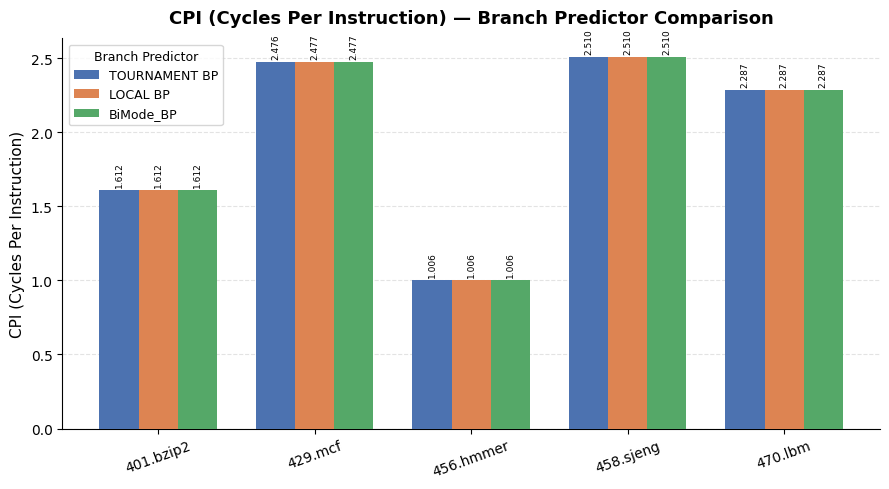

  Saved → initalStep_CPI_bar.png


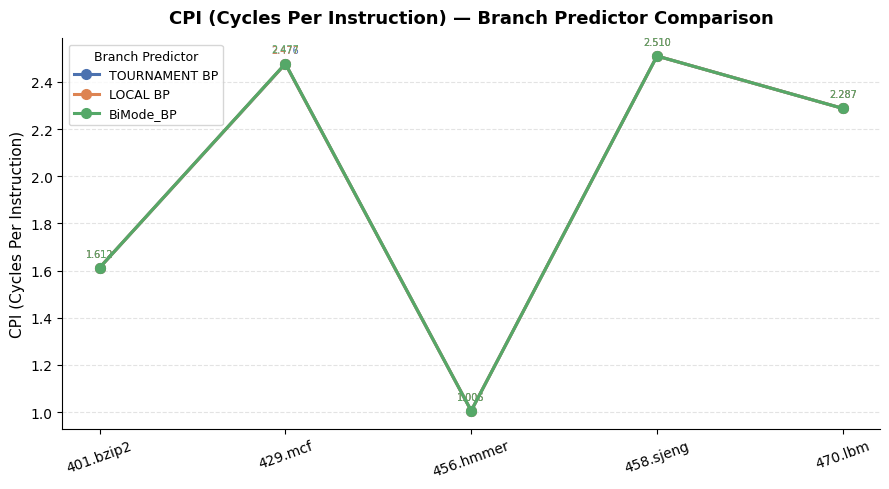

  Saved → initalStep_CPI_line.png


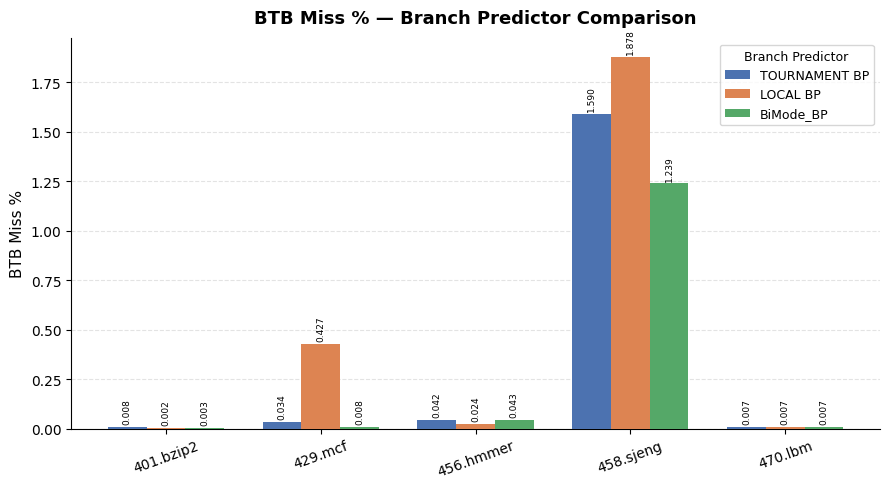

  Saved → initalStep_btbMissPct_bar.png


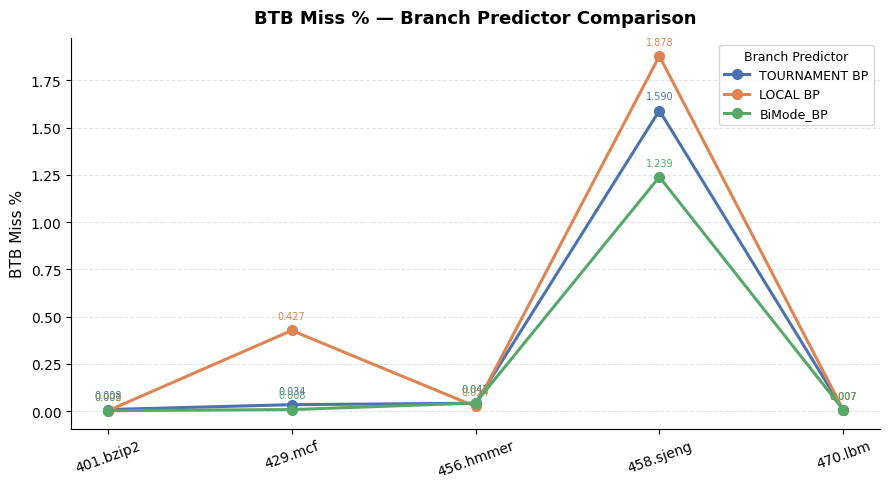

  Saved → initalStep_btbMissPct_line.png


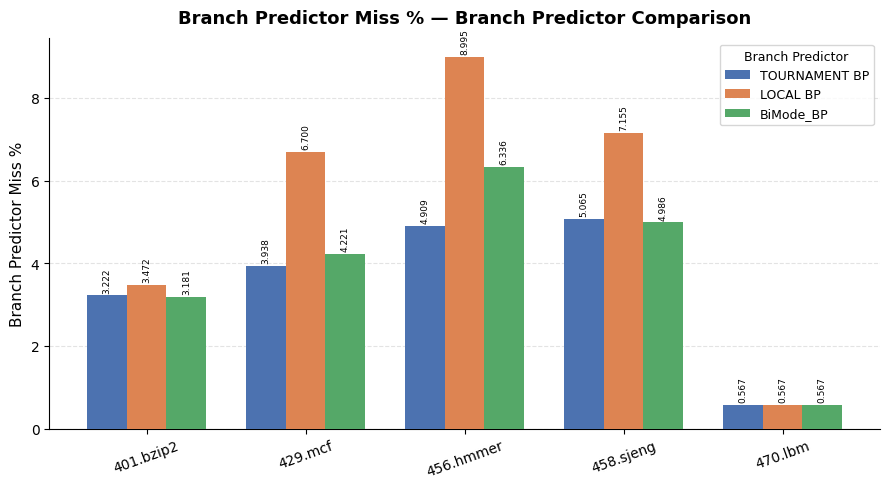

  Saved → initalStep_branchMisPredPct_bar.png


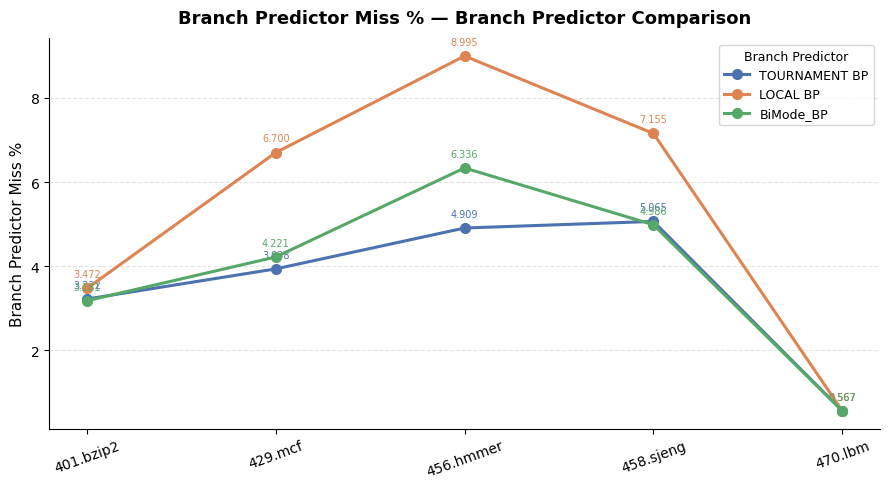

  Saved → initalStep_branchMisPredPct_line.png
Done.


In [2]:
"""
plot_bp_clean.py
----------------
Reads a clean CSV with columns:
  predictor, benchmark, CPI, btbMissPct, branchMisPredPct

Produces a bar chart and line chart for each metric (6 PNGs total).

Usage (terminal):
  python plot_bp_clean.py bp_data_clean.csv

Usage (Colab/Jupyter — edit NOTEBOOK_CONFIG below):
  Just run the cell.
"""

import csv
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

# ── COLAB / JUPYTER CONFIG ────────────────────────────────────────────────────
NOTEBOOK_CONFIG = {
    "filepath": "bp_data_clean.csv",  # ← change to your file path
    "output":   "initalStep",                  # ← output prefix, or None = filename
}
# ─────────────────────────────────────────────────────────────────────────────

METRICS = ["CPI", "btbMissPct", "branchMisPredPct"]
METRIC_LABELS = {
    "CPI":              "CPI (Cycles Per Instruction)",
    "btbMissPct":       "BTB Miss %",
    "branchMisPredPct": "Branch Predictor Miss %",
}
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]


def is_notebook():
    try:
        return get_ipython().__class__.__name__ in ("ZMQInteractiveShell", "Shell")  # noqa
    except NameError:
        return False


def parse_args():
    if is_notebook():
        class A:
            filepath = NOTEBOOK_CONFIG["filepath"]
            output   = NOTEBOOK_CONFIG["output"]
        return A()
    import argparse
    p = argparse.ArgumentParser(description="Plot branch predictor comparison charts from clean CSV.")
    p.add_argument("filepath", help="Path to the clean CSV file")
    p.add_argument("--output", default=None, help="Output filename prefix")
    return p.parse_args()


def load_data(filepath):
    """Return (predictors, benchmarks, data)
       data = { predictor: { benchmark: { metric: float } } }
    """
    data       = {}
    predictors = []
    benchmarks = []

    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            bp    = row["predictor"].strip()
            bench = row["benchmark"].strip()

            if bp not in data:
                data[bp] = {}
                predictors.append(bp)
            if bench not in benchmarks:
                benchmarks.append(bench)

            data[bp][bench] = {
                "CPI":              float(row["CPI"]),
                "btbMissPct":       float(row["btbMissPct"]),
                "branchMisPredPct": float(row["branchMisPredPct"]),
            }

    return predictors, benchmarks, data


def make_bar_chart(predictors, benchmarks, data, metric, base):
    fig, ax = plt.subplots(figsize=(max(9, len(benchmarks) * 1.5), 5))

    n, x, w = len(predictors), np.arange(len(benchmarks)), 0.75 / len(predictors)
    for i, bp in enumerate(predictors):
        vals   = [data[bp].get(b, {}).get(metric, 0) for b in benchmarks]
        offset = (i - (n - 1) / 2) * w
        bars   = ax.bar(x + offset, vals, width=w,
                        label=bp, color=COLORS[i % len(COLORS)], zorder=3)
        ax.bar_label(bars, fmt="%.3f", fontsize=6.5, padding=2, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks)
    ax.set_title(f"{METRIC_LABELS[metric]} — Branch Predictor Comparison",
                 fontsize=13, fontweight="bold", pad=11)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelrotation=20)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.legend(title="Branch Predictor", fontsize=9, title_fontsize=9)
    fig.tight_layout()

    path = f"{base}_{metric}_bar.png"
    fig.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved → {path}")


def make_line_chart(predictors, benchmarks, data, metric, base):
    fig, ax = plt.subplots(figsize=(max(9, len(benchmarks) * 1.5), 5))

    x = np.arange(len(benchmarks))
    for i, bp in enumerate(predictors):
        vals  = [data[bp].get(b, {}).get(metric, 0) for b in benchmarks]
        color = COLORS[i % len(COLORS)]
        ax.plot(x, vals, marker="o", linewidth=2.2, markersize=7,
                label=bp, color=color, zorder=3)
        for xi, yi in zip(x, vals):
            ax.annotate(f"{yi:.3f}", xy=(xi, yi),
                        xytext=(0, 8), textcoords="offset points",
                        ha="center", fontsize=7, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks)
    ax.set_title(f"{METRIC_LABELS[metric]} — Branch Predictor Comparison",
                 fontsize=13, fontweight="bold", pad=11)
    ax.set_ylabel(METRIC_LABELS[metric], fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelrotation=20)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.legend(title="Branch Predictor", fontsize=9, title_fontsize=9)
    fig.tight_layout()

    path = f"{base}_{metric}_line.png"
    fig.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved → {path}")


def main():
    args = parse_args()
    if not os.path.isfile(args.filepath):
        sys.exit(f"Error: file not found – {args.filepath}")

    predictors, benchmarks, data = load_data(args.filepath)
    print(f"Predictors : {predictors}")
    print(f"Benchmarks : {benchmarks}\n")

    base = args.output or os.path.splitext(args.filepath)[0]
    for metric in METRICS:
        make_bar_chart(predictors, benchmarks, data, metric, base)
        make_line_chart(predictors, benchmarks, data, metric, base)

    print("Done.")


main()